In [133]:
import numpy as np
import matplotlib.pyplot as plt
import os
os.environ["TORCH_LOAD_WEIGHTS_ONLY"] = "0"
import torch
from torch import nn
from torch.nn import functional as F
from torch import optim
from torchvision import datasets
from torchvision.transforms import v2
from torch.utils.data import random_split
from torch.utils.data import DataLoader
from tqdm.notebook import tqdm
import uuid
import shutil
from google.colab import drive
import itertools
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern
import gc
import copy
import hashlib
import json
import time
import random

In [134]:
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [135]:
# torch.serialization.add_safe_globals([
#     np._core.multiarray.scalar,
#     np.dtype
# ])

# _original_torch_load = torch.load

# def _patched_torch_load(*args, **kwargs):
#     kwargs['weights_only'] = False
#     return _original_torch_load(*args, **kwargs)

# torch.load = _patched_torch_load

In [136]:
CHECKPOINT_DIR = "/content/checkpoints"
os.makedirs(CHECKPOINT_DIR, exist_ok=True)

In [137]:
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(DEVICE) # Should be cuda

cuda


In [138]:
CNN_MEAN = [0.485, 0.456, 0.406]
CNN_STD = [0.229, 0.224, 0.225]
transforms = v2.Compose([
    v2.ToImage(),
    v2.ToDtype(torch.float32, scale=True),
    v2.Normalize(mean=CNN_MEAN, std=CNN_STD),
    # resize(32, 32)
    v2.Resize((32, 32), antialias=True),
])

train_split = 0.8
BATCH_SIZE = 64

train_data_init = datasets.CIFAR10(root="data", train=True, download=True, transform=transforms)
test_data = datasets.CIFAR10(root="data", train=False, download=True, transform=transforms)

train_sample_size = int(len(train_data_init) * train_split)
val_sample_size = len(train_data_init) - train_sample_size

train_data, val_data = random_split(train_data_init, [train_sample_size, val_sample_size], generator=torch.Generator().manual_seed(42)) # manual seed for reproducability

TRAIN_DATALOADER = DataLoader(train_data, batch_size=BATCH_SIZE)
VAL_DATALOADER = DataLoader(val_data, batch_size=BATCH_SIZE)
TEST_DATALOADER = DataLoader(test_data, batch_size=BATCH_SIZE)

hyperparameters = {
    "filters_conv1": [16, 32, 64],
    "filters_conv2": [32, 64, 128],
    "fc_features": [64, 128, 256, 512],
    "dropout_rate": [0, 0.25, 0.5],
    "activation":  [nn.ReLU, nn.LeakyReLU, nn.ELU, nn.GELU],
    "optimizer": [optim.Adam, optim.AdamW, optim.RMSprop, optim.SGD],
    "learning_rate": [1, 0.1, 0.01, 0.001, 0.0001]
}



In [139]:
class ConvNeuralNetwork(nn.Module):
  def __init__(self, hyperparameters):
    super(ConvNeuralNetwork, self).__init__()

    filters_conv1 = hyperparameters['filters_conv1']
    filters_conv2 = hyperparameters['filters_conv2']
    fc_features = hyperparameters['fc_features']
    dropout_rate = hyperparameters['dropout_rate']

    self.conv1 = nn.Conv2d(3, filters_conv1, kernel_size=3, padding=1, stride=1)
    self.bn1 = nn.BatchNorm2d(filters_conv1)
    self.conv2 = nn.Conv2d(filters_conv1, filters_conv2, kernel_size=3, padding=1, stride=1)
    self.bn2 = nn.BatchNorm2d(filters_conv2)

    self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
    self.dropout = nn.Dropout(dropout_rate)

    self.fc1 = nn.Linear(filters_conv2 * 8 * 8, fc_features)
    self.fc2 = nn.Linear(fc_features, 10)

    self.activation = hyperparameters['activation']()

  def forward(self, x):

    x = self.pool(self.activation(self.bn1(self.conv1(x))))
    x = self.pool(self.activation(self.bn2(self.conv2(x))))

    x = torch.flatten(x, 1)

    x = self.dropout(self.activation(self.fc1(x)))
    x = self.fc2(x)

    return x

In [140]:
def train(model, loss_function, optimizer, epochs, start_epoch=0):

  train_history = {
      "train_loss": [],
      "train_acc": [],
      "val_loss": [],
      "val_acc": []
  }

  for epoch in tqdm(range(start_epoch, epochs)):
    model.train()
    total_train_loss = 0
    total_val_loss = 0

    total_train_correct = 0
    total_val_correct = 0

    for (inputs, labels) in TRAIN_DATALOADER:
        (inputs, labels) = (inputs.to(DEVICE), labels.to(DEVICE))

        optimizer.zero_grad()

        pred = model(inputs)
        loss = loss_function(pred, labels)

        loss.backward()
        optimizer.step()

        total_train_loss += loss
        total_train_correct += (pred.argmax(1) == labels).type(torch.float).sum().item()

    model.eval()
    with torch.no_grad():

        for (inputs, labels) in VAL_DATALOADER:
            (inputs, labels) = (inputs.to(DEVICE), labels.to(DEVICE))

            pred = model(inputs)
            loss = loss_function(pred, labels)

            total_val_loss += loss
            total_val_correct += (pred.argmax(1) == labels).type(torch.float).sum().item()

    # Train and Val Steps
    avg_train_loss = total_train_loss / len(TRAIN_DATALOADER.dataset)
    avg_val_loss = total_val_loss / len(VAL_DATALOADER.dataset)

    # train_acc = total_train_correct / (batch_size * len(TRAIN_DATALOADER.dataset))
    #val_acc = total_val_correct / (batch_size * len(VAL_DATALOADER.dataset))
    train_acc = total_train_correct / (len(TRAIN_DATALOADER.dataset))
    val_acc = total_val_correct / (len(VAL_DATALOADER.dataset))

    train_history["train_loss"].append(avg_train_loss.cpu().detach().numpy())
    train_history["train_acc"].append(train_acc)
    train_history["val_loss"].append(avg_val_loss.cpu().detach().numpy())
    train_history["val_acc"].append(val_acc)

  return train_history

In [141]:
def test(model, loss_function, optimizer):
    model.eval()

    total_test_loss = 0
    total_test_correct = 0

    with torch.no_grad():
      for (inputs, labels) in TEST_DATALOADER:
          (inputs, labels) = (inputs.to(DEVICE), labels.to(DEVICE))

          pred = model(inputs)
          loss = loss_function(pred, labels)

          total_test_loss += loss
          total_test_correct += (pred.argmax(1) == labels).type(torch.float).sum().item()

    avg_test_loss = total_test_loss / len(TEST_DATALOADER.dataset)
    # test_acc = total_test_correct / (batch_size * len(TEST_DATALOADER.dataset))
    test_acc = total_test_correct / (len(TEST_DATALOADER.dataset))


    return avg_test_loss, test_acc

In [142]:
def save_model(model, optimizer, epoch, path):
  torch.save({
      "epoch": epoch,
      "model": model.state_dict(),
      "optimizer": optimizer.state_dict()
      }, path)

In [143]:
def load_model(model, optimizer, path):
  checkpoint = torch.load(path, weights_only=False)
  model.load_state_dict(checkpoint["model"])
  optimizer.load_state_dict(checkpoint["optimizer"])
  epoch = checkpoint["epoch"]

  return model, optimizer, epoch

In [144]:
def generate_save_id(hyperparameters):
  hparam_string = json.dumps(hyperparameters, sort_keys=True, default=lambda x: x.__name__ if hasattr(x, '__name__') else str(x))
  return hashlib.md5(hparam_string.encode()).hexdigest()[:10]

In [146]:
def get_params(hyperparameters):
  config = {k: np.random.choice(v) for k, v in hyperparameters.items()}
  return config

In [147]:
def vectorize_hyperparameters(hyperparameters):
  activation_map = {nn.ReLU: 0, nn.LeakyReLU: 1, nn.ELU: 2, nn.GELU: 3}
  optimizer_map = {optim.Adam: 0, optim.AdamW: 1, optim.RMSprop: 2, optim.SGD: 3}

  # normalize all numerical params by max so in scale 0-1
  vector_hyperparameters = [
      hyperparameters['filters_conv1'] / 64,
      hyperparameters['filters_conv2'] / 128,
      hyperparameters['fc_features'] / 512,
      hyperparameters['dropout_rate'],
      activation_map[hyperparameters['activation']] / 3,
      optimizer_map[hyperparameters['optimizer']] / 3,
      np.log10(hyperparameters['learning_rate']) #/ -4 # log scale for hyperparams
  ]
  return np.array(vector_hyperparameters).reshape(1, -1)

In [148]:
def RandomSearch(hyperparameters, num_trials, r):
  best_val_loss = np.inf
  best_hyperparameters = None

  results = []

  for i in range(num_trials):
    hyperparameter_config = get_params(hyperparameters)

    model = ConvNeuralNetwork(hyperparameter_config).to(DEVICE)
    optimizer = hyperparameter_config["optimizer"](model.parameters(), lr=hyperparameter_config['learning_rate'])
    loss_function = nn.CrossEntropyLoss()

    history = train(model, loss_function, optimizer, r)

    results.append(history)

    if min(history["val_loss"]) < best_val_loss:
      best_val_loss = min(history["val_loss"])
      best_hyperparameters = hyperparameter_config
      #best_model = model

    del model, optimizer, loss_function, history
    torch.cuda.empty_cache()
    import gc
    gc.collect()


  return best_hyperparameters, best_val_loss, results

In [149]:
def run_model_hyperband(hyperparameter_config, r):

  hyperparameters = hyperparameter_config["hyperparameters"]
  path = f"{hyperparameter_config["save_id"]}_checkpoint.pt"

  model = ConvNeuralNetwork(hyperparameters).to(DEVICE)
  optimizer = hyperparameters["optimizer"](model.parameters(), lr=hyperparameters['learning_rate'])
  loss_function = nn.CrossEntropyLoss()

  start_epoch = 0
  if os.path.exists(path):
    model, optimizer, start_epoch = load_model(model, optimizer, path)

    # Shouldnt happen but fallback if start epochs exceeds budgeted epoch
    if start_epoch >= r:
      print(f"{hyperparameter_config["save_id"]} already has met budgeted resources.")
      return hyperparameter_config["loss"]

  history = train(model, loss_function, optimizer, r, start_epoch)
  final_loss = history["val_loss"][-1]

  hyperparameter_config["loss"] = final_loss
  hyperparameter_config["total_r"] = r

  save_model(model, optimizer, r, path)

  del model, optimizer, history
  torch.cuda.empty_cache()
  import gc
  gc.collect()


  return final_loss

def top_k(configs, losses, n_i, eta):
  sorted_idx = np.argsort(losses)
  top_k = max(1, int(np.floor(n_i / eta)))

  keep_idx = sorted_idx[:top_k]
  discared_idx = sorted_idx[top_k:]
  new_configs = [configs[idx] for idx in keep_idx]

  for idx in discared_idx:
    discard_id = configs[idx]["save_id"]
    path = f"{discard_id}_checkpoint.pt"
    if os.path.exists(path):
      os.remove(path)

  return new_configs

def HyperBand(hyperparameters, R, eta):
  results = []

  s_max = int(np.floor(np.log(R) / np.log(eta)))
  B = (s_max + 1) * R

  for s in range(s_max, -1, -1):
    n = int(np.ceil(B/R * (eta ** s) / (s+1)))
    r = R * (eta ** -s)

    hyperparameter_configs = []
    for _ in range(n):
      hparams = get_params(hyperparameters)
      hyperparameter_configs.append({
          "hyperparameters": hparams,
          "save_id": generate_save_id(hparams), # str(uuid.uuid4())[:8], # so that i can identify the checkpointed models
          "total_r": 0,
          "loss": 0.0 })

    for i in range(s+1):
      n_i = n * (eta ** -i)
      r_i = int(r * (eta ** i))

      val_losses = []

      for config in hyperparameter_configs:

        val_loss = run_model_hyperband(config, r_i)
        val_losses.append(val_loss)
        results.append((copy.deepcopy(config), val_loss, r_i))

      hyperparameter_configs = top_k(hyperparameter_configs, val_losses, n_i, eta)

  best_entry = min(results, key=lambda res: res[1])

  best_hyperparameters = best_entry[0]["hyperparameters"]
  best_loss = best_entry[1]

  return best_hyperparameters, best_loss, results

In [150]:
def find_best_hyperparameters(gp, hyperparameters, num_candidates):
  candidates = [get_params(hyperparameters) for _ in range(num_candidates)]
  vector_candidates = np.vstack([vectorize_hyperparameters(config) for config in candidates])

  try:
    means, std_devs = gp.predict(vector_candidates, return_std=True)
    kappa = 2.0
    acquisition_values = means - kappa * std_devs
    best_candidate = candidates[np.argmin(acquisition_values)]
  except:
    best_candidate = random.choice(candidates)

  return best_candidate


def BOHyperBand(hyperparameters, R, eta):
  results = []
  D = []

  s_max = int(np.floor(np.log(R) / np.log(eta)))
  B = (s_max + 1) * R

  gp = GaussianProcessRegressor(kernel = Matern(nu=2.5), alpha=1e-6) # since hyperparameter space likely non differentiable use this instead of rbf
  #opt = Optimizer(dimension=len(hyperparameters), base_estimator=gp)

  for s in range(s_max, -1, -1):
    n = int(np.ceil(B/R * (eta ** s) / (s+1)))
    r = R * (eta ** -s)

    hyperparameter_configs = []

    for i in range(s+1):
      n_i = int(np.floor(n * (eta ** -i)))
      r_i = int(r * (eta ** i))

      if i == 0:

        for t in range(n_i):

          new_hyperparameters = get_params(hyperparameters)

          if len(D) > 5:

            all_vectors = [d[0] for d in D]
            all_losses = [d[1] for d in D]

            valid_indices = [i for i, loss in enumerate(all_losses) if not np.isnan(loss)]
            if len(valid_indices) > 5:
              gp_hyperparameters = np.vstack([all_vectors[i] for i in valid_indices])
              gp_losses = np.array([all_losses[i] for i in valid_indices])

              try:
                gp.fit(gp_hyperparameters, gp_losses)
                new_hyperparameters = find_best_hyperparameters(gp, hyperparameters, 1000)
              except:
                pass

          new_config = {
              "hyperparameters": new_hyperparameters,
              "save_id": generate_save_id(new_hyperparameters), # str(uuid.uuid4())[:8], # so that i can identify the checkpointed models
              "total_r": 0,
              "loss": 0.0 }

          val_loss = run_model_hyperband(new_config, r_i)
          hyperparameter_configs.append(new_config)
          vector_hyperparameters = vectorize_hyperparameters(new_config["hyperparameters"])
          D.append((vector_hyperparameters, val_loss))
          results.append((copy.deepcopy(new_config), val_loss, r_i))

      else:

        val_losses = []

        for config in hyperparameter_configs:

          val_loss = run_model_hyperband(config, r_i)
          val_losses.append(val_loss)
          results.append((copy.deepcopy(config), val_loss, r_i))

        hyperparameter_configs = top_k(hyperparameter_configs, val_losses, n_i, eta)

  best_entry = min(results, key=lambda res: res[1])

  best_hyperparameters = best_entry[0]["hyperparameters"]
  best_loss = best_entry[1]

  return best_hyperparameters, best_loss, results

In [151]:
def run_model_linucb(hyperparameters, r):
    model = ConvNeuralNetwork(hyperparameters).to(DEVICE)
    optimizer = hyperparameters["optimizer"](model.parameters(), lr=hyperparameters['learning_rate'])
    loss_function = nn.CrossEntropyLoss()

    history = train(model, loss_function, optimizer, r)
    val_loss = history["val_loss"][-1]

    del model, optimizer, history
    torch.cuda.empty_cache()
    import gc
    gc.collect()

    return val_loss

In [152]:
# def rbf_kernel(x1, x2, sigma):
#   return np.exp(-np.sum((x1 - x2) ** 2, axis=1) / (2 * sigma ** 2))

def LinUCB(hyperparameters, num_trials, gamma, _lambda, r):
  keys = hyperparameters.keys()
  combinations = [dict(zip(keys, values)) for values in itertools.product(*hyperparameters.values())]

  vector_hyperparameters = np.array([vectorize_hyperparameters(config).flatten() for config in combinations])
  n, d = vector_hyperparameters.shape

  #V0 = gamma * np.eye(d)
  V = (1 / gamma) * np.eye(d)
  b = np.zeros((d, 1))
  #V = np.linalg.inv(V)

  results = []

  for t in range(num_trials):

    theta_hat = V @ b

    means = vector_hyperparameters @ theta_hat
    std_devs = np.sqrt(np.diag(vector_hyperparameters @ V @ vector_hyperparameters.T)).reshape(-1, 1)

    #beta_t = 0.1 * np.sqrt(np.log(t + 1)) + np.sqrt(gamma)
    beta_t = gamma * np.sqrt(np.log(t + 1))

    score = means + beta_t * std_devs

    action = np.argmax(score)
    chosen_config = combinations[action]
    vector_chosen = vector_hyperparameters[action].reshape(-1, 1)

    val_loss = run_model_linucb(chosen_config, r)
    #reward = 1 - val_loss # should i use validation accuracy?
    reward = 1 / (1 + val_loss)

    V = V - ( (V @ vector_chosen @ vector_chosen.T @ V) ) / (1 + vector_chosen.T @ V @ vector_chosen)
    b = b + vector_chosen * reward

    results.append((chosen_config, val_loss))

  best_entry = min(results, key=lambda res: res[1])

  best_hyperparameters = best_entry[0]
  best_loss = best_entry[1]

  return best_hyperparameters, best_loss, results

In [153]:
def train_best_model(hyperparameters, epochs):

  model = ConvNeuralNetwork(hyperparameters).to(DEVICE)
  optimizer = hyperparameters["optimizer"](model.parameters(), lr=hyperparameters['learning_rate'])
  loss_function = nn.CrossEntropyLoss()

  history = train(model, loss_function, optimizer, epochs, start_epoch=0)

  test_loss, test_acc = test(model, loss_function, optimizer)

  return model, history, test_loss

Running BOHyperband


  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

...

  0%|          | 0/9 [00:00<?, ?it/s]

  0%|          | 0/9 [00:00<?, ?it/s]

  0%|          | 0/9 [00:00<?, ?it/s]

  0%|          | 0/9 [00:00<?, ?it/s]

  0%|          | 0/9 [00:00<?, ?it/s]

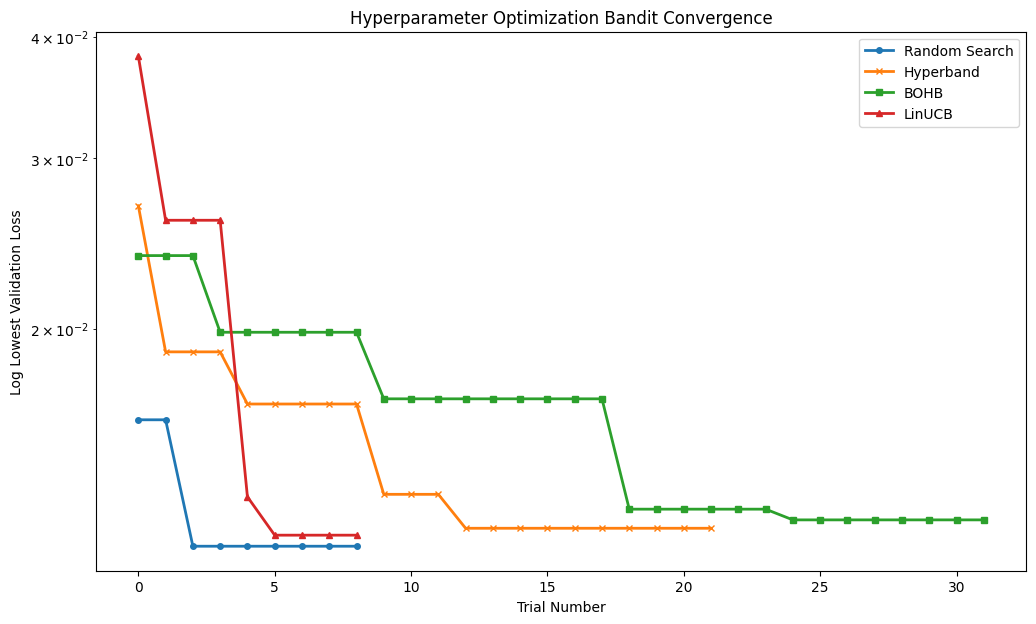

Random Search Time: 1519.0484609603882
Hyperband Time: 1296.4963698387146
BO Hyperband Time: 1969.915429353714
LinUCB Time: 1525.8731663227081
Random Search Best Hyperparameters: {'filters_conv1': np.int64(64), 'filters_conv2': np.int64(32), 'fc_features': np.int64(256), 'dropout_rate': np.float64(0.5), 'activation': <class 'torch.nn.modules.activation.ELU'>, 'optimizer': <class 'torch.optim.adamw.AdamW'>, 'learning_rate': np.float64(0.001)}
Hyperband Best Hyperparameters: {'filters_conv1': np.int64(32), 'filters_conv2': np.int64(32), 'fc_features': np.int64(256), 'dropout_rate': np.float64(0.5), 'activation': <class 'torch.nn.modules.activation.ELU'>, 'optimizer': <class 'torch.optim.adam.Adam'>, 'learning_rate': np.float64(0.001)}
BO Hyperband Best Hyperparameters: {'filters_conv1': np.int64(64), 'filters_conv2': np.int64(128), 'fc_features': np.int64(256), 'dropout_rate': np.float64(0.5), 'activation': <class 'torch.nn.modules.activation.ReLU'>, 'optimizer': <class 'torch.optim.adam

  0%|          | 0/30 [00:00<?, ?it/s]

  0%|          | 0/30 [00:00<?, ?it/s]

  0%|          | 0/30 [00:00<?, ?it/s]

  0%|          | 0/30 [00:00<?, ?it/s]

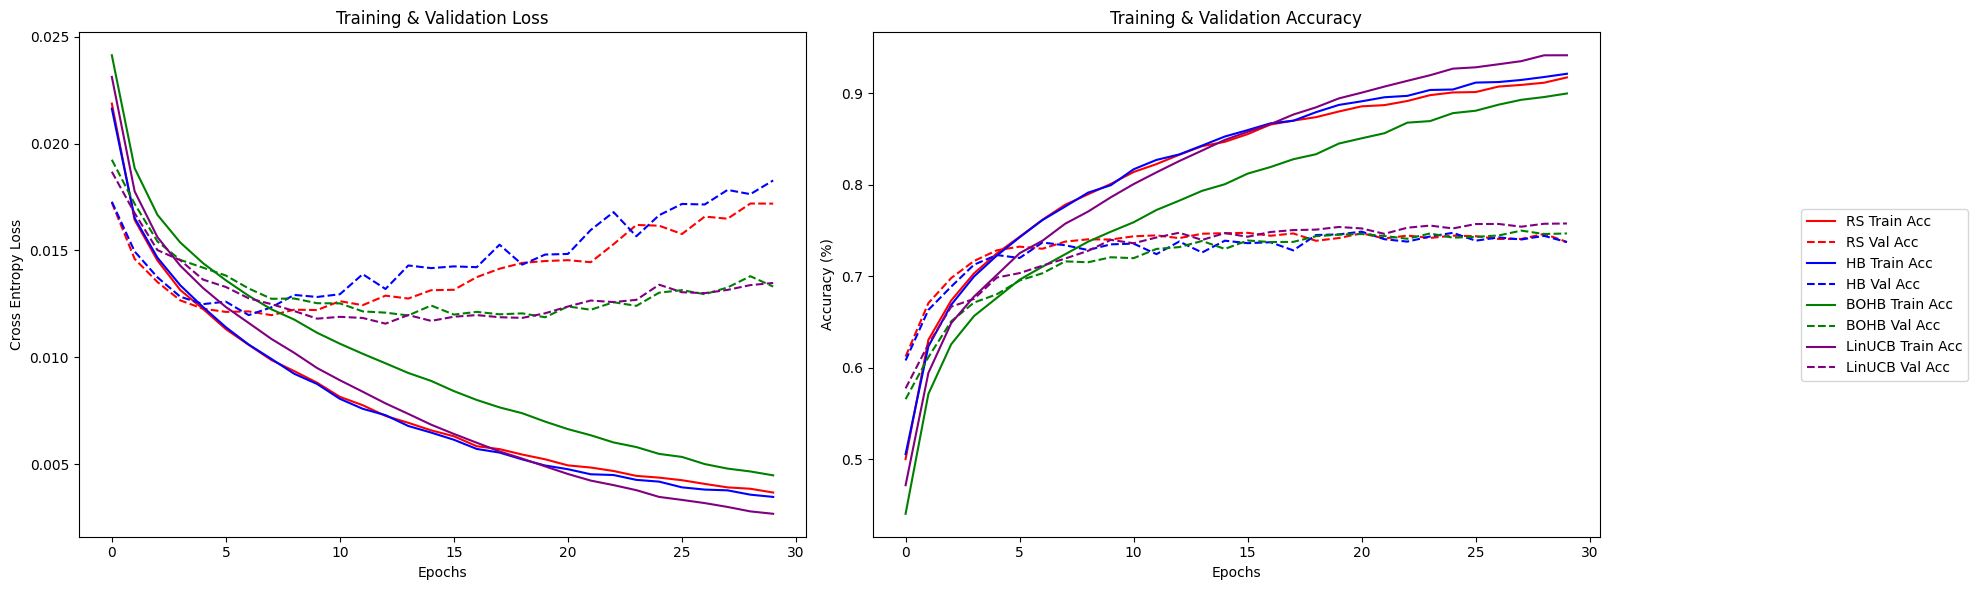

In [154]:
print("Running BOHyperband")
tic = time.time()
bohb_hyperparameters, bohb_best_loss, bohb_results = BOHyperBand(hyperparameters, R=9, eta=3)
toc = time.time()
bohb_time = toc - tic

print("Running LinUCB")
tic = time.time()
lin_ucb_hyperparameters, linucb_best_loss, linucb_results = LinUCB(hyperparameters, num_trials=9, gamma=0.1, _lambda=1, r=9)
toc = time.time()
linucb_time = toc - tic

print("Running Hyperband")
tic = time.time()
hb_hyperparameters, hb_best_loss, hb_results = HyperBand(hyperparameters, R=9, eta=3)
toc = time.time()
hb_time = toc - tic

print("Running Random Search")
tic = time.time()
rs_hyperparameters, rs_best_loss, rs_results = RandomSearch(hyperparameters, num_trials=9, r=9)
toc = time.time()
rs_time = toc - tic

plt.figure(figsize=(12, 7))

def get_best_so_far(losses):
    return [min(losses[:i+1]) for i in range(len(losses))]

rs_losses = [min(h["val_loss"]) for h in rs_results]
plt.plot(get_best_so_far(rs_losses), label='Random Search', linewidth=2, marker='o', markersize=4)

hb_losses = [res[1] for res in hb_results]
plt.plot(get_best_so_far(hb_losses), label='Hyperband', linewidth=2, marker='x', markersize=4)

bohb_losses = [res[1] for res in bohb_results]
plt.plot(get_best_so_far(bohb_losses), label='BOHB', linewidth=2, marker='s', markersize=4)

linucb_losses = [res[1] for res in linucb_results]
plt.plot(get_best_so_far(linucb_losses), label='LinUCB', linewidth=2, marker='^', markersize=4)

plt.yscale('log')
plt.title("Hyperparameter Optimization Bandit Convergence")
plt.xlabel("Trial Number")
plt.ylabel("Log Lowest Validation Loss")
plt.legend()
plt.show()

print(f"Random Search Time: {rs_time}")
print(f"Hyperband Time: {hb_time}")
print(f"BO Hyperband Time: {bohb_time}")
print(f"LinUCB Time: {linucb_time}")

print(f"Random Search Best Hyperparameters: {rs_hyperparameters}")
print(f"Hyperband Best Hyperparameters: {hb_hyperparameters}")
print(f"BO Hyperband Best Hyperparameters: {bohb_hyperparameters}")
print(f"LinUCB Best Hyperparameters: {lin_ucb_hyperparameters}")

rs_final_model, rs_final_history, rs_final_test_loss = train_best_model(rs_hyperparameters, 30)
hb_final_model, hb_final_history, hb_final_test_loss = train_best_model(hb_hyperparameters, 30)
bohb_final_model, bohb_final_history, bohb_final_test_loss = train_best_model(bohb_hyperparameters, 30)
linucb_final_model, linucb_final_history, linucb_final_test_loss = train_best_model(lin_ucb_hyperparameters, 30)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6))

ax1.plot(rs_final_history['train_loss'], color='red', label='RS Train Loss')
ax1.plot(rs_final_history['val_loss'], color='red', linestyle='--', label='RS Val Loss')
ax1.plot(hb_final_history['train_loss'], color='blue', label='HB Train Loss')
ax1.plot(hb_final_history['val_loss'], color='blue', linestyle='--', label='HB Val Loss')
ax1.plot(bohb_final_history['train_loss'], color='green', label='BOHB Train Loss')
ax1.plot(bohb_final_history['val_loss'], color='green', linestyle='--', label='BOHB Val Loss')
ax1.plot(linucb_final_history['train_loss'], color='purple', label='LinUCB Train Loss')
ax1.plot(linucb_final_history['val_loss'], color='purple', linestyle='--', label='LinUCB Val Loss')

ax1.set_title("Training & Validation Loss")
ax1.set_xlabel("Epochs")
ax1.set_ylabel("Cross Entropy Loss")

ax2.plot(rs_final_history['train_acc'], color='red', label='RS Train Acc')
ax2.plot(rs_final_history['val_acc'], color='red', linestyle='--', label='RS Val Acc')
ax2.plot(hb_final_history['train_acc'], color='blue', label='HB Train Acc')
ax2.plot(hb_final_history['val_acc'], color='blue', linestyle='--', label='HB Val Acc')
ax2.plot(bohb_final_history['train_acc'], color='green', label='BOHB Train Acc')
ax2.plot(bohb_final_history['val_acc'], color='green', linestyle='--', label='BOHB Val Acc')
ax2.plot(linucb_final_history['train_acc'], color='purple', label='LinUCB Train Acc')
ax2.plot(linucb_final_history['val_acc'], color='purple', linestyle='--', label='LinUCB Val Acc')

ax2.set_title("Training & Validation Accuracy")
ax2.set_xlabel("Epochs")
ax2.set_ylabel("Accuracy (%)")

handles, labels = ax2.get_legend_handles_labels()
fig.legend(handles, labels, loc='center right', bbox_to_anchor=(1.1, 0.5))

plt.tight_layout(rect=[0, 0, 0.9, 1])
plt.show()

In [158]:
rs_final_optimizer = rs_hyperparameters["optimizer"](rs_final_model.parameters(), lr=rs_hyperparameters['learning_rate'])
hb_final_optimizer = hb_hyperparameters["optimizer"](hb_final_model.parameters(), lr=hb_hyperparameters['learning_rate'])
bohb_final_optimizer = bohb_hyperparameters["optimizer"](bohb_final_model.parameters(), lr=bohb_hyperparameters['learning_rate'])
linucb_final_optimizer = lin_ucb_hyperparameters["optimizer"](linucb_final_model.parameters(), lr=lin_ucb_hyperparameters['learning_rate'])
loss_function = nn.CrossEntropyLoss()

rs_test_loss, rs_test_acc = test(rs_final_model, loss_function, rs_final_optimizer)
hb_test_loss, hb_test_acc = test(hb_final_model, loss_function, hb_final_optimizer)
bohb_test_loss, bohb_test_acc = test(bohb_final_model, loss_function, bohb_final_optimizer)
linucb_test_loss, linucb_test_acc = test(linucb_final_model, loss_function, linucb_final_optimizer)

print(f"Random Search Test Loss: {rs_test_loss:.4f} Test Accuracy: {rs_test_acc:.2f}")
print(f"Hyperband Test Loss: {hb_test_loss:.4f} Test Accuracy: {hb_test_acc:.2f}")
print(f"BO Hyperband Test Loss: {bohb_test_loss:.4f} Test Accuracy: {bohb_test_acc:.2f}")
print(f"LinUCB Test Loss: {linucb_test_loss:.4f} Test Accuracy: {linucb_test_acc:.2f}")

Random Search Test Loss: 0.0173 Test Accuracy: 0.74
Hyperband Test Loss: 0.0183 Test Accuracy: 0.73
BO Hyperband Test Loss: 0.0135 Test Accuracy: 0.75
LinUCB Test Loss: 0.0136 Test Accuracy: 0.76


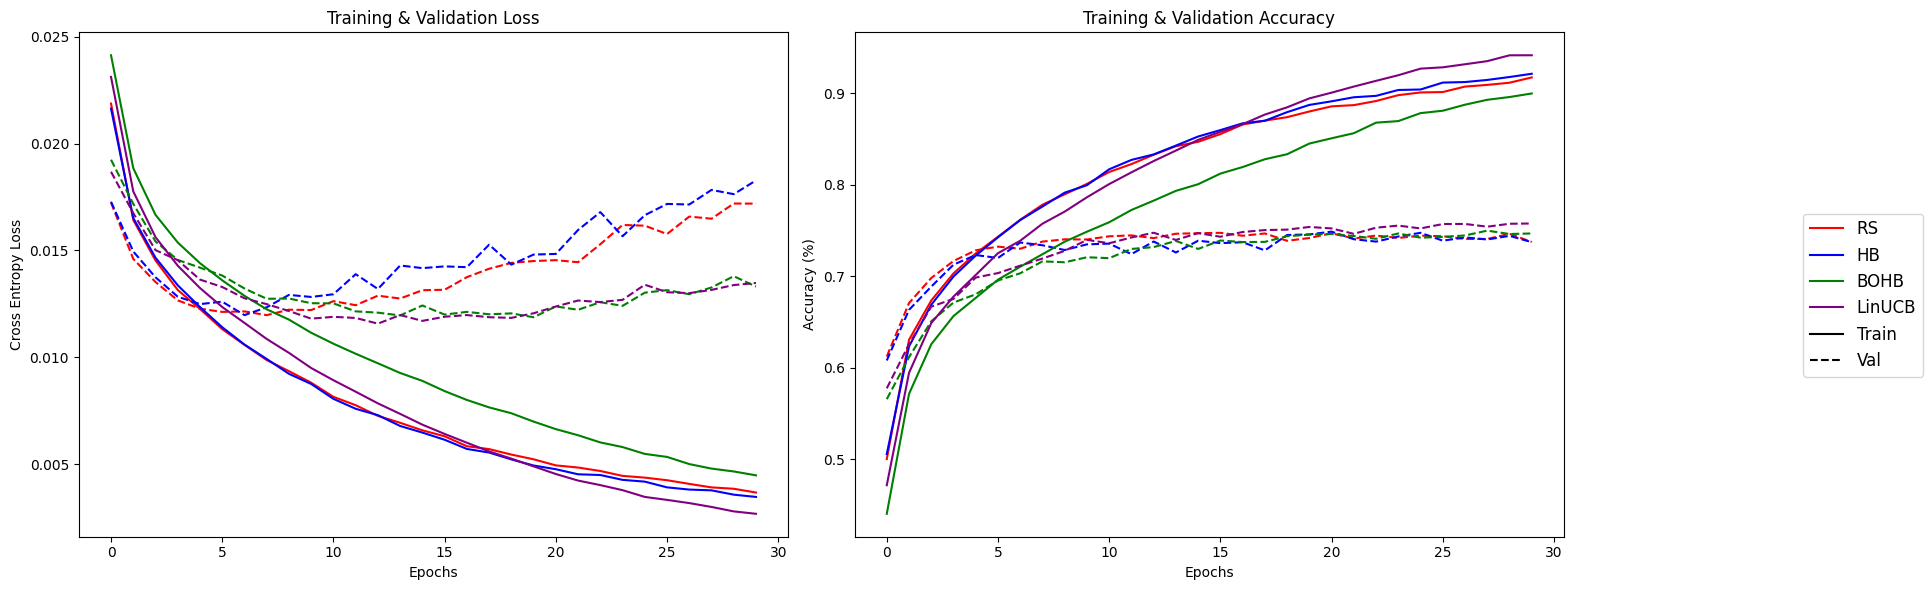

In [159]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6))

ax1.plot(rs_final_history['train_loss'], color='red', label='RS')
ax1.plot(rs_final_history['val_loss'], color='red', linestyle='--')
ax1.plot(hb_final_history['train_loss'], color='blue', label='HB')
ax1.plot(hb_final_history['val_loss'], color='blue', linestyle='--')
ax1.plot(bohb_final_history['train_loss'], color='green', label='BOHB')
ax1.plot(bohb_final_history['val_loss'], color='green', linestyle='--')
ax1.plot(linucb_final_history['train_loss'], color='purple', label='LinUCB')
ax1.plot(linucb_final_history['val_loss'], color='purple', linestyle='--')

ax1.set_title("Training & Validation Loss")
ax1.set_xlabel("Epochs")
ax1.set_ylabel("Cross Entropy Loss")

ax2.plot(rs_final_history['train_acc'], color='red')
ax2.plot(rs_final_history['val_acc'], color='red', linestyle='--')
ax2.plot(hb_final_history['train_acc'], color='blue')
ax2.plot(hb_final_history['val_acc'], color='blue', linestyle='--')
ax2.plot(bohb_final_history['train_acc'], color='green')
ax2.plot(bohb_final_history['val_acc'], color='green', linestyle='--')
ax2.plot(linucb_final_history['train_acc'], color='purple')
ax2.plot(linucb_final_history['val_acc'], color='purple', linestyle='--')

ax2.set_title("Training & Validation Accuracy")
ax2.set_xlabel("Epochs")
ax2.set_ylabel("Accuracy (%)")

from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], color='red', label='RS'),
    Line2D([0], [0], color='blue', label='HB'),
    Line2D([0], [0], color='green', label='BOHB'),
    Line2D([0], [0], color='purple', label='LinUCB'),
    Line2D([0], [0], color='black', label='Train', linestyle='-'),
    Line2D([0], [0], color='black', label='Val', linestyle='--'),
]

fig.legend(handles=legend_elements, loc='center left', bbox_to_anchor=(1.0, 0.5), fontsize=12)

plt.tight_layout(rect=[0, 0, 0.88, 1])
plt.show()